# Regresion Cuantilica Espacial en Medellin con PySQReg

**Aplicacion con datos reales** — Encuesta de Calidad de Vida a nivel de barrio.

Este notebook aplica la regresion cuantilica espacial (SAR quantile model) a datos
reales de **269 barrios de Medellin**, usando indicadores agregados de la
Encuesta de Calidad de Vida (ECV) del municipio.

**Pregunta de investigacion:** Como varia el efecto del estrato socioeconomico
y la educacion sobre el ingreso mediano a lo largo de la distribucion condicional?
Los barrios de ingresos bajos (cuantiles inferiores) y altos (cuantiles superiores)
responden de manera diferente a estas variables?

### Contenido
1. Carga y exploracion de datos
2. Construccion de la matriz de pesos espaciales (queen contiguity)
3. Test de autocorrelacion espacial (Moran's I)
4. Estimacion del modelo SAR cuantilico
5. Proceso cuantilico: como varian los efectos
6. Impactos espaciales directos e indirectos
7. Diagnosticos residuales

### Fuentes de datos
- **Geometria de barrios:** Centro Nacional de Memoria Historica (CNMH) / ArcGIS
- **Indicadores socioeconomicos:** Encuesta de Calidad de Vida, MEData - Alcaldia de Medellin

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
from scipy.sparse import lil_matrix, csc_matrix, diags
from shapely.geometry import shape
from shapely.ops import unary_union

from pysqreg import QuantSAR, QuantSLX, QuantSDM, moran_test
from pysqreg.plots import (
    plot_moran,
    fit_quantile_process,
    plot_quantile_process,
    plot_rho_path,
)

np.random.seed(42)
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

---
## 1. Carga y exploracion de datos

Cargamos los indicadores agregados a nivel de barrio y la geometria de los poligonos.

In [2]:
# Cargar datos agregados por barrio
df = pd.read_csv('barrios_ecv_aggregated.csv')
print(f"Barrios: {len(df)}")
print(f"Comunas: {df['comuna'].nunique()}")
print()
df.describe().round(2)

Barrios: 271
Comunas: 16



,comuna,n_personas,n_hogares,avg_estrato,avg_edad,avg_educacion,median_ingreso,avg_ingreso,pct_sin_ingreso,lon,lat
count,271.00,271.00,271.00,271.00,271.00,271.00,271.00,271.00,271.00,271.00,271.00
mean,8.90,1124.24,2.48,2.96,37.93,3.25,859973.71,1150309.63,0.76,-75.58,6.26
std,4.42,951.15,1.13,1.10,5.03,0.84,338695.41,593529.37,0.03,0.02,0.03
min,1.00,0.00,0.00,1.01,22.20,1.77,400000.00,400000.00,0.67,-75.63,6.18
25%,5.00,380.50,3.00,2.08,34.05,2.58,675000.00,759999.00,0.74,-75.60,6.24
50%,9.00,960.00,3.00,2.80,37.50,3.12,737717.00,924722.38,0.76,-75.58,6.26
75%,13.00,1623.50,3.00,3.64,41.40,3.88,900000.00,1287071.00,0.78,-75.56,6.28
max,16.00,4463.00,3.00,5.58,58.20,5.30,2600000.00,3477161.00,0.91,-75.53,6.31


In [3]:
# Cargar geometria de barrios y construir indice por nombre
with open('Barrios_Medellin.geojson') as f:
    geojson = json.load(f)

# Crear indice nombre -> feature
geo_by_name = {}
for feat in geojson['features']:
    name = feat['properties']['Nombre_Barrio'].strip()
    geo_by_name[name] = feat

# Asociar geometrias a los barrios del dataset
geometries = []
valid_idx = []
for i, row in df.iterrows():
    name = row['barrio_name']
    if name in geo_by_name:
        geometries.append(shape(geo_by_name[name]['geometry']))
        valid_idx.append(i)

df = df.loc[valid_idx].reset_index(drop=True)
print(f"Barrios con geometria: {len(df)}")

# Marcar barrios imputados (n_personas == 0 indica imputacion por comuna)
df['imputado'] = df['n_personas'] == 0
n_real = (~df['imputado']).sum()
n_imp = df['imputado'].sum()
print(f"  Datos reales (ECV): {n_real}")
print(f"  Imputados por comuna: {n_imp}")

# Variables para el modelo
# y = log(median_ingreso) - ingreso mediano por barrio
# X = [avg_estrato, avg_educacion, avg_edad]
df['log_ingreso'] = np.log(df['median_ingreso'])
print(f"\nVariables del modelo:")
print(f"  y: log(ingreso mediano) - rango [{df['log_ingreso'].min():.2f}, {df['log_ingreso'].max():.2f}]")
print(f"  x1: estrato promedio    - rango [{df['avg_estrato'].min():.2f}, {df['avg_estrato'].max():.2f}]")
print(f"  x2: educacion promedio  - rango [{df['avg_educacion'].min():.2f}, {df['avg_educacion'].max():.2f}]")
print(f"  x3: edad promedio       - rango [{df['avg_edad'].min():.1f}, {df['avg_edad'].max():.1f}]")

Barrios con geometria: 271
  Datos reales (ECV): 225
  Imputados por comuna: 46

Variables del modelo:
  y: log(ingreso mediano) - rango [12.90, 14.77]
  x1: estrato promedio    - rango [1.01, 5.58]
  x2: educacion promedio  - rango [1.77, 5.30]
  x3: edad promedio       - rango [22.2, 58.2]


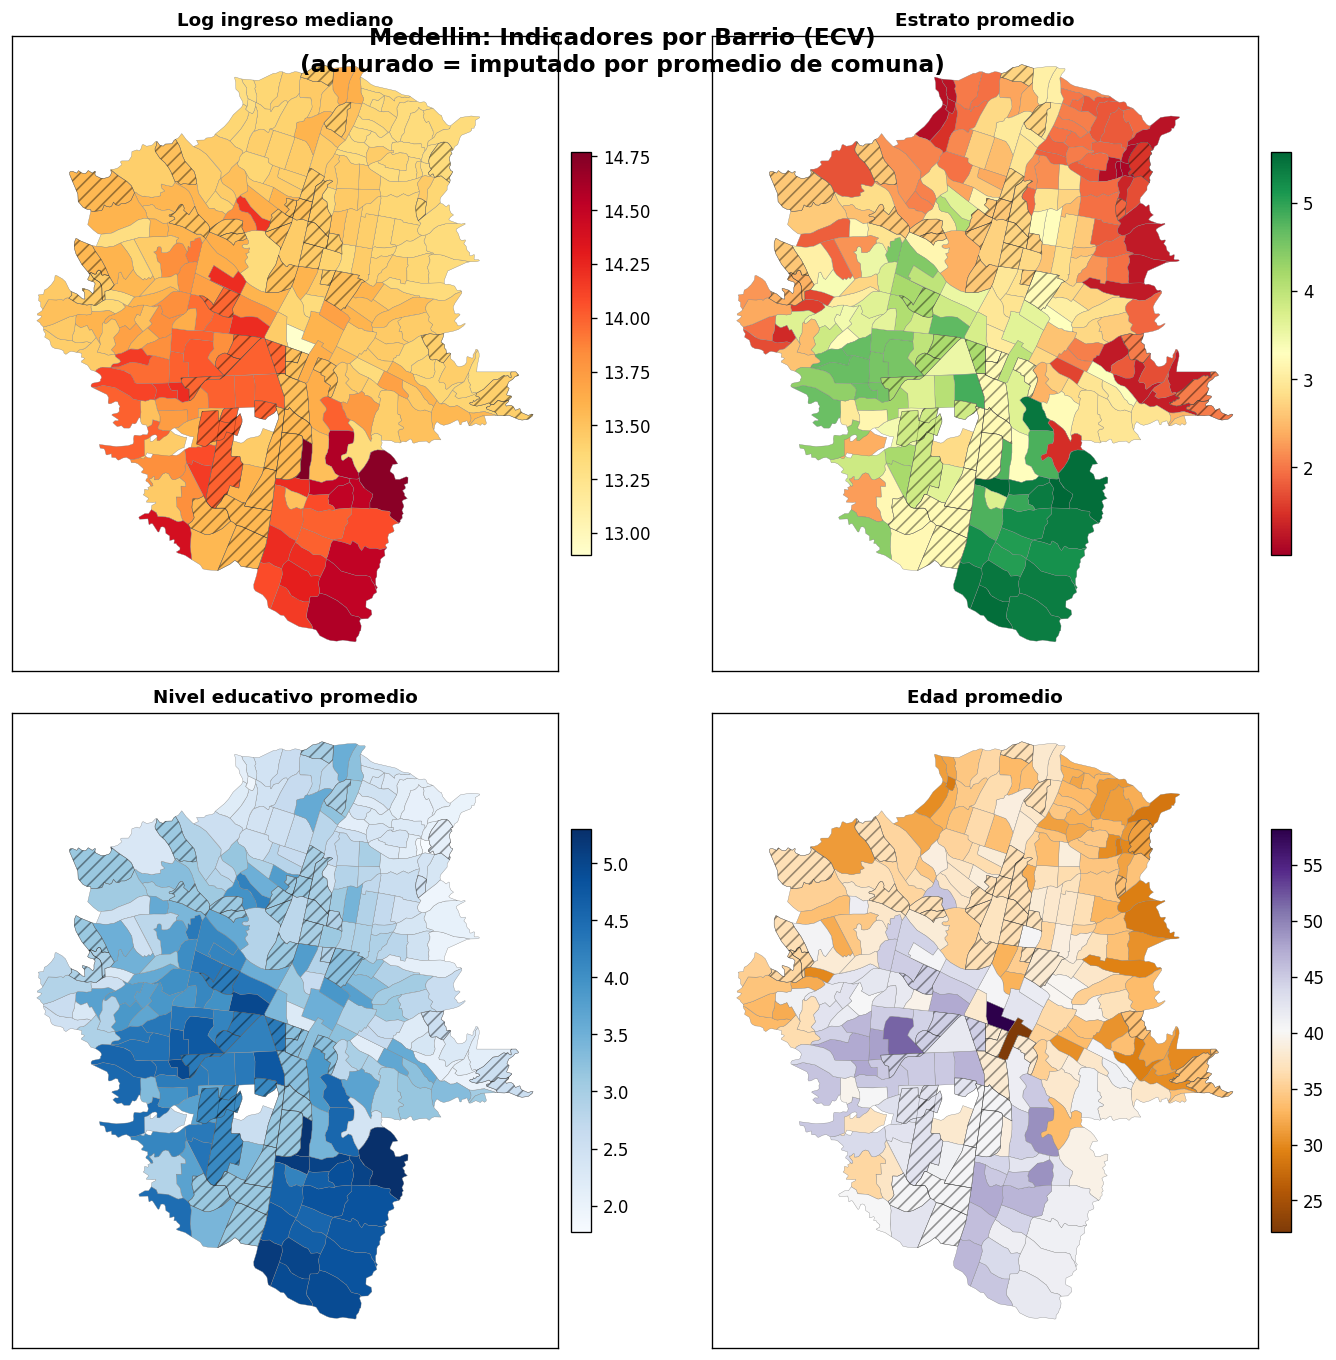

In [4]:
# Mapa coropletico de las variables principales
from matplotlib.collections import PatchCollection
from matplotlib.patches import Polygon as MplPolygon
from matplotlib.colors import Normalize

def plot_choropleth(geometries, values, ax, title, cmap='YlOrRd', imputado=None):
    "Dibuja un mapa coropletico. Barrios imputados se marcan con achurado."
    norm = Normalize(vmin=values.min(), vmax=values.max())
    patches = []
    colors = []
    imp_patches = []
    
    for k, (geom, val) in enumerate(zip(geometries, values)):
        is_imp = imputado[k] if imputado is not None else False
        polys = []
        if geom.geom_type == 'Polygon':
            polys = [geom]
        elif geom.geom_type == 'MultiPolygon':
            polys = list(geom.geoms)
        for poly in polys:
            coords = np.array(poly.exterior.coords)
            mpoly = MplPolygon(coords[:, :2], closed=True)
            patches.append(mpoly)
            colors.append(val)
            if is_imp:
                imp_patches.append(MplPolygon(coords[:, :2], closed=True))
    
    pc = PatchCollection(patches, cmap=cmap, norm=norm, edgecolor='gray', linewidth=0.2)
    pc.set_array(np.array(colors))
    ax.add_collection(pc)
    
    # Achurado sobre barrios imputados
    if imp_patches:
        pc_imp = PatchCollection(imp_patches, facecolor='none', edgecolor='black',
                                  linewidth=0.3, hatch='///', alpha=0.4)
        ax.add_collection(pc_imp)
    
    ax.autoscale()
    ax.set_aspect('equal')
    ax.set_title(title, fontsize=11, fontweight='semibold')
    ax.set_xticks([])
    ax.set_yticks([])
    return pc

fig, axes = plt.subplots(2, 2, figsize=(12, 12))

vars_to_plot = [
    ('log_ingreso', 'Log ingreso mediano', 'YlOrRd'),
    ('avg_estrato', 'Estrato promedio', 'RdYlGn'),
    ('avg_educacion', 'Nivel educativo promedio', 'Blues'),
    ('avg_edad', 'Edad promedio', 'PuOr'),
]

for ax, (col, title, cmap) in zip(axes.flat, vars_to_plot):
    pc = plot_choropleth(geometries, df[col].values, ax, title, cmap,
                         imputado=df['imputado'].values)
    plt.colorbar(pc, ax=ax, fraction=0.03, pad=0.02)

fig.suptitle('Medellin: Indicadores por Barrio (ECV)\n'
             '(achurado = imputado por promedio de comuna)',
             fontsize=14, fontweight='bold', y=0.93)
plt.tight_layout()
plt.show()

---
## 2. Matriz de pesos espaciales

Construimos una matriz de **queen contiguity** a partir de los poligonos de los barrios:
dos barrios son vecinos si sus geometrias se tocan o comparten un borde.
Luego estandarizamos por filas para que cada fila sume 1.

In [5]:
def queen_contiguity_from_polygons(geometries):
    """Construye una matriz queen contiguity row-standardizada desde poligonos."""
    n = len(geometries)
    W = lil_matrix((n, n))
    
    # Buffering minimo para capturar vecinos que se tocan en un punto
    buffered = [g.buffer(0.0001) for g in geometries]
    
    for i in range(n):
        for j in range(i + 1, n):
            if buffered[i].intersects(buffered[j]):
                W[i, j] = 1.0
                W[j, i] = 1.0
    
    W = W.tocsr()
    row_sums = np.array(W.sum(axis=1)).ravel()
    
    # Barrios sin vecinos: asignar los mas cercanos por centroide
    centroids = np.array([[g.centroid.x, g.centroid.y] for g in geometries])
    islands = np.where(row_sums == 0)[0]
    if len(islands) > 0:
        print(f"  {len(islands)} barrios aislados (sin vecinos por contigueidad)")
        from scipy.spatial.distance import cdist
        for idx in islands:
            dists = cdist([centroids[idx]], centroids)[0]
            dists[idx] = np.inf
            # Conectar a los 3 mas cercanos
            nearest = np.argsort(dists)[:3]
            for nn in nearest:
                W[idx, nn] = 1.0
                W[nn, idx] = 1.0
        W = W.tocsr()
        row_sums = np.array(W.sum(axis=1)).ravel()
    
    # Row-standardize
    row_sums[row_sums == 0] = 1.0
    W = diags(1.0 / row_sums) @ W
    return W.tocsc()

print("Construyendo matriz de pesos espaciales...")
W = queen_contiguity_from_polygons(geometries)
n = len(df)

# Estadisticas de la matriz
nnz = W.nnz
avg_neighbors = nnz / n
print(f"  Barrios: {n}")
print(f"  Conexiones: {nnz}")
print(f"  Vecinos promedio: {avg_neighbors:.1f}")
print(f"  Rango de vecinos: {int(np.array(W.astype(bool).sum(axis=1)).min())} - {int(np.array(W.astype(bool).sum(axis=1)).max())}")

Construyendo matriz de pesos espaciales...
  Barrios: 271
  Conexiones: 1596
  Vecinos promedio: 5.9
  Rango de vecinos: 1 - 11


---
## 3. Test de Autocorrelacion Espacial — Moran's I

Antes de modelar la dependencia espacial, verificamos que exista.
Aplicamos Moran's I al ingreso y al estrato para confirmar clustering espacial.

In [6]:
# Moran's I sobre el log-ingreso
print("=== Moran's I: Log ingreso mediano ===")
result_ingreso = moran_test(df['log_ingreso'].values, W)
result_ingreso.summary()

print("\n=== Moran's I: Estrato promedio ===")
result_estrato = moran_test(df['avg_estrato'].values, W)
result_estrato.summary()

=== Moran's I: Log ingreso mediano ===
  Moran's I Test for Spatial Autocorrelation
  Moran's I statistic :  0.638441
  Expected value E[I] : -0.003704
  Variance Var[I]     :  0.001287
  Z-score             :  17.8992
  p-value (two-sided) :  0.000000
  Assumption          : randomization
  N                   : 271
-------------------------------------------------------
  Significant POSITIVE spatial autocorrelation

=== Moran's I: Estrato promedio ===
  Moran's I Test for Spatial Autocorrelation
  Moran's I statistic :  0.752232
  Expected value E[I] : -0.003704
  Variance Var[I]     :  0.001298
  Z-score             :  20.9826
  p-value (two-sided) :  0.000000
  Assumption          : randomization
  N                   : 271
-------------------------------------------------------
  Significant POSITIVE spatial autocorrelation


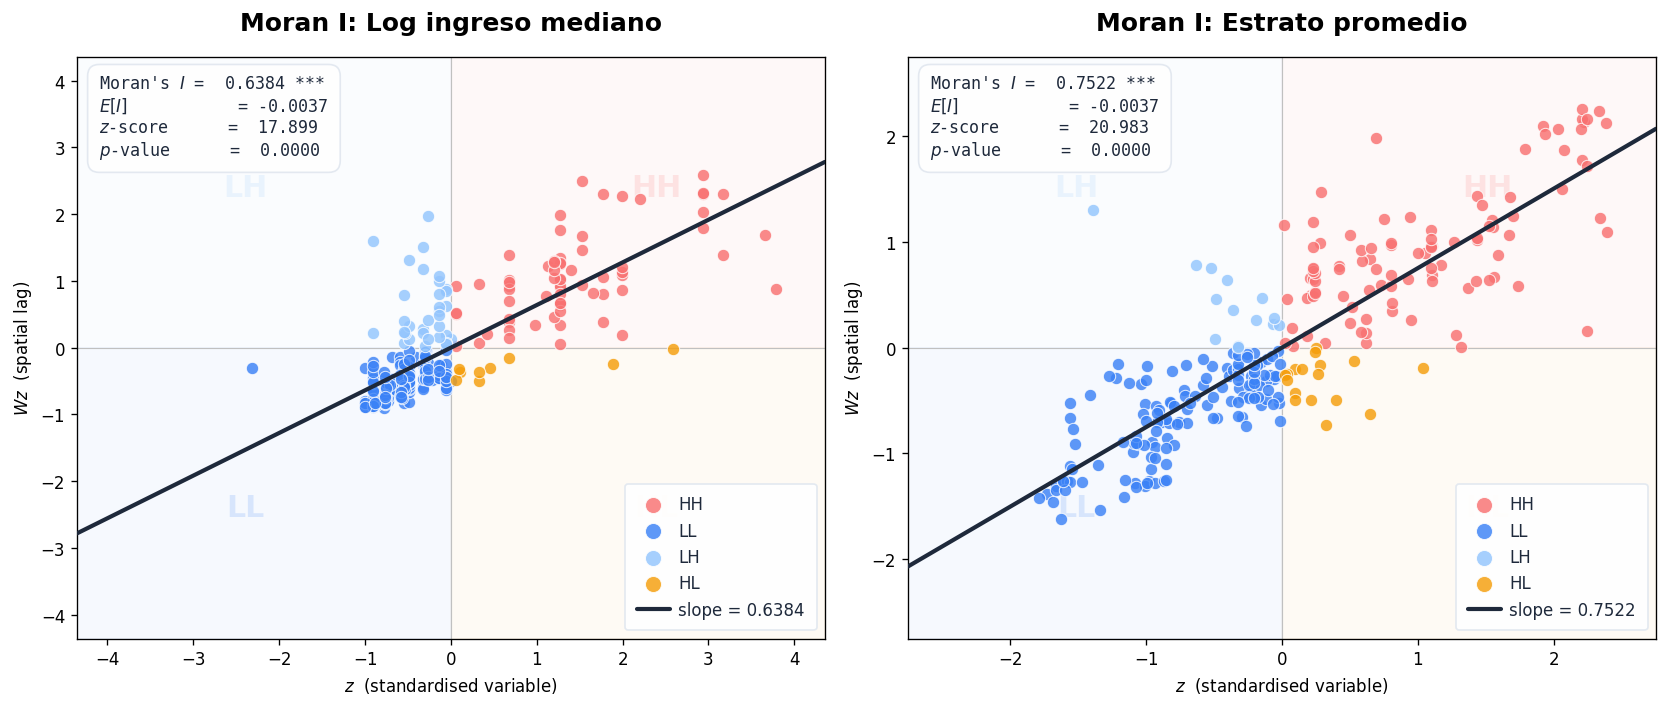

In [7]:
# Moran scatterplot del log-ingreso
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plot_moran(df['log_ingreso'].values, W, ax=axes[0], title='Moran I: Log ingreso mediano')
plot_moran(df['avg_estrato'].values, W, ax=axes[1], title='Moran I: Estrato promedio')
plt.tight_layout()
plt.show()

La autocorrelacion espacial positiva significativa confirma que barrios cercanos
tienen ingresos y estratos similares — hay **clustering espacial** claro en Medellin.
Esto justifica usar un modelo SAR en lugar de regresion clasica.

---
## 4. Estimacion del Modelo SAR Cuantilico

Estimamos el modelo:

$$y_i = \rho \sum_j w_{ij} y_j + \beta_1 \cdot \text{estrato}_i + \beta_2 \cdot \text{educacion}_i + \beta_3 \cdot \text{edad}_i + u_i$$

donde $y_i$ = log(ingreso mediano) del barrio $i$.

### 4.1 Modelo en la mediana ($\tau = 0.5$) — Dos metodos

In [8]:
# Preparar variables
y = df['log_ingreso'].values

# Usar DataFrame para que PySQReg preserve los nombres de las columnas
X = df[['avg_estrato', 'avg_educacion', 'avg_edad']].rename(
    columns={'avg_estrato': 'Estrato', 'avg_educacion': 'Educacion', 'avg_edad': 'Edad'}
)

print(f"n = {len(y)}, k = {X.shape[1]}")
print(f"y (log ingreso): mean={y.mean():.3f}, std={y.std():.3f}")

n = 271, k = 3
y (log ingreso): mean=13.610, std=0.306


In [9]:
# Metodo 1: Kim & Muller (Two-Stage IV Quantile Regression)
model_ts = QuantSAR(tau=0.5, method='two_stage', nboot=300, random_state=42)
model_ts.fit(X, y, W)
model_ts.summary()

Kim & Muller Two-Stage Quantile Regression
Quantile: tau = 0.5
1. MODEL COEFFICIENTS
---------------------------------------------------------------------------
               Coef.  Bootstrap SE  Z-values  Pr(>|z|)
(Intercept) 12.85980       0.73730  17.44172   0.00000
Estrato      0.03253       0.03380   0.96243   0.33583
Educacion    0.35178       0.03886   9.05261   0.00000
Edad        -0.02121       0.00549  -3.86508   0.00011
WY           0.02194       0.05649   0.38847   0.69767

2. SPATIAL IMPACTS (LeSage & Pace)
---------------------------------------------------------------------------
            Direct  SE Direct  Indirect (Spillover)  SE Indirect  p-val Indirect    Total  SE Total
Estrato    0.03254    0.03385               0.00072      0.00349         0.83613  0.03326   0.03599
Educacion  0.35187    0.03875               0.00781      0.02173         0.71923  0.35968   0.03758
Edad      -0.02121    0.00550              -0.00047      0.00147         0.74825 -0.02168   0.005

,Coef.,Bootstrap SE,Z-values,Pr(>|z|)
(Intercept),12.859795,0.737301,17.441724,0.000000
Estrato,0.032532,0.033802,0.962429,0.335834
Educacion,0.351783,0.038860,9.052609,0.000000
Edad,-0.021208,0.005487,-3.865081,0.000111
WY,0.021943,0.056486,0.388471,0.697667


In [10]:
# Metodo 2: Chernozhukov & Hansen (Grid-Search IVQR)
model_gs = QuantSAR(tau=0.5, method='grid_search',
                     rhomat=np.arange(-0.9, 0.91, 0.01))
model_gs.fit(X, y, W)
model_gs.summary()

Chernozhukov & Hansen IV Quantile Regression
Quantile: tau = 0.5
1. MODEL COEFFICIENTS
---------------------------------------------------------------------------
               Coef.  Std. Err.  Z-Values  Pr(>|z|)
(Intercept) 12.65208    0.66106  19.13908   0.00000
Estrato      0.03366    0.02345   1.43553   0.15114
Educacion    0.35109    0.03009  11.66635   0.00000
Edad        -0.02222    0.00245  -9.05820   0.00000
WY           0.04000    0.05108   0.78313   0.43355

2. SPATIAL IMPACTS (LeSage & Pace)
---------------------------------------------------------------------------
            Direct  SE Direct  Indirect (Spillover)  SE Indirect  p-val Indirect    Total  SE Total
Estrato    0.03367    0.02345               0.00139      0.00193         0.47043  0.03506   0.02418
Educacion  0.35119    0.03005               0.01453      0.01897         0.44359  0.36572   0.03298
Edad      -0.02223    0.00245              -0.00092      0.00122         0.45261 -0.02315   0.00289


,Coef.,Std. Err.,Z-Values,Pr(>|z|)
(Intercept),12.652081,0.661060,19.139078,0.000000
Estrato,0.033659,0.023447,1.435532,0.151135
Educacion,0.351090,0.030094,11.666349,0.000000
Edad,-0.022224,0.002453,-9.058202,0.000000
WY,0.040000,0.051077,0.783127,0.433552


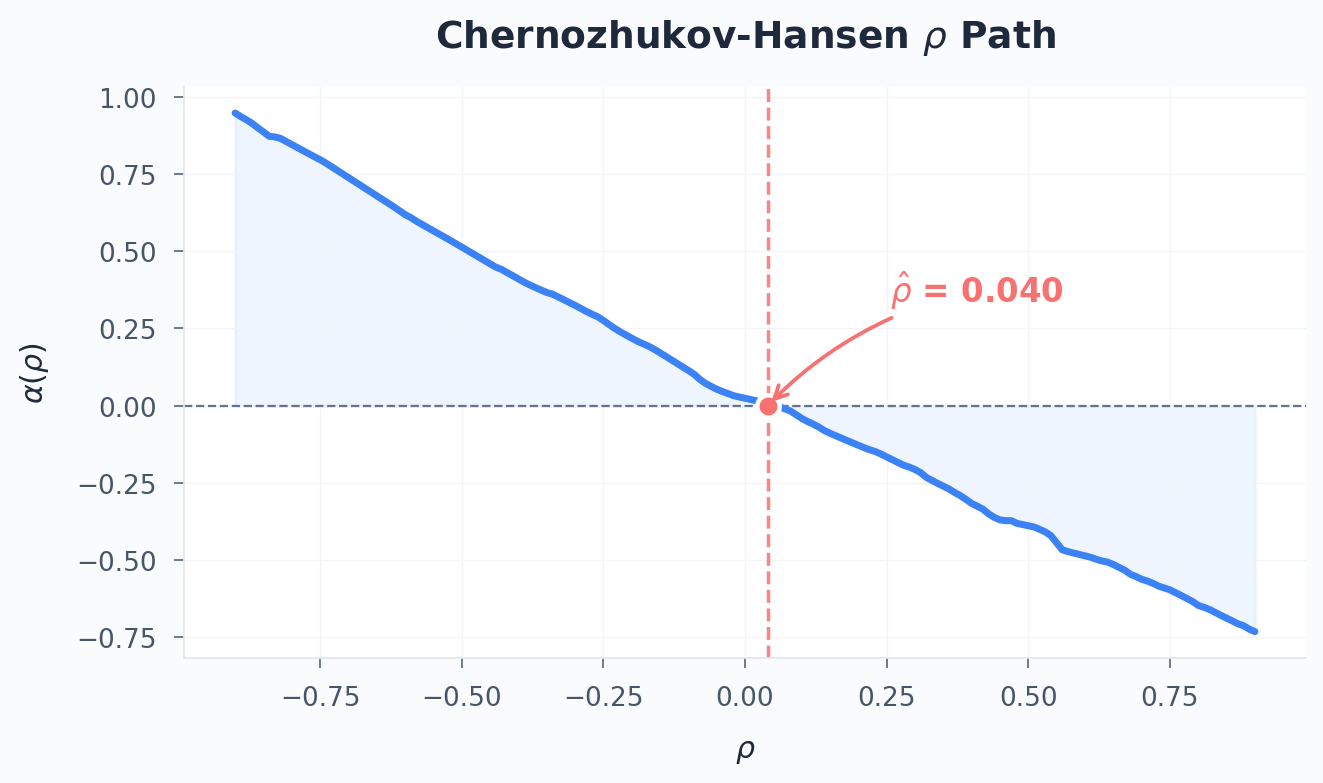

In [11]:
# Rho path — visualizar la seleccion de rho en grid search
plot_rho_path(model_gs)
plt.show()

### 4.2 Modelos alternativos: SLX y SDM

PySQReg tambien implementa:
- **QuantSLX**: Modelo con rezagos espaciales solo en las X (sin lag en y)
- **QuantSDM**: Spatial Durbin Model (lag en y + lags en X)

In [12]:
# SLX: Solo rezagos espaciales en X
model_slx = QuantSLX(tau=0.5, nboot=200, random_state=42)
model_slx.fit(X, y, W)
model_slx.summary()

SLX Quantile Regression  (y = Xβ + WXθ + u)
Quantile: tau = 0.5
               Coef.  Std. Err.  Z-values  Pr(>|z|)
(Intercept) 13.24663    0.12990 101.97529   0.00000
Estrato      0.03630    0.02572   1.41138   0.15813
Educacion    0.34277    0.03156  10.86204   0.00000
Edad        -0.01959    0.00245  -8.00466   0.00000
W*Estrato   -0.03335    0.04033  -0.82691   0.40829
W*Educacion  0.09525    0.05636   1.69008   0.09101
W*Edad      -0.00899    0.00537  -1.67412   0.09411


,Coef.,Std. Err.,Z-values,Pr(>|z|)
(Intercept),13.246633,0.129900,101.975290,0.000000e+00
Estrato,0.036304,0.025722,1.411380,1.581325e-01
Educacion,0.342772,0.031557,10.862039,0.000000e+00
Edad,-0.019595,0.002448,-8.004658,1.110223e-15
W*Estrato,-0.033353,0.040334,-0.826906,4.082905e-01
W*Educacion,0.095252,0.056359,1.690076,9.101332e-02
W*Edad,-0.008986,0.005368,-1.674123,9.410641e-02


In [ ]:
# SDM: Spatial Durbin Model (lag en y + lags en X)
model_sdm = QuantSDM(tau=0.5, method='two_stage', nboot=200, random_state=42)
model_sdm.fit(X, y, W)
model_sdm.summary()

---
## 5. Proceso Cuantilico

El verdadero poder de la regresion cuantilica es ver **como cambian los efectos
a lo largo de la distribucion**. Estimamos el modelo para $\tau \in \{0.10, 0.15, \ldots, 0.90\}$.

Si los coeficientes varian significativamente entre cuantiles, esto indica
heterogeneidad distribucional que OLS no puede capturar.

In [ ]:
# Ajustar el proceso cuantilico
taus = np.arange(0.10, 0.91, 0.05)

qp = fit_quantile_process(
    X, y, W,
    taus=taus,
    method='two_stage',
    nboot=200,
    random_state=42,
    verbose=1,
)


  Fitting quantile 0.10  [1/17]


  Fitting quantile 0.15  [2/17]


  Fitting quantile 0.20  [3/17]


  Fitting quantile 0.25  [4/17]


  Fitting quantile 0.30  [5/17]

...


  Fitting quantile 0.70  [13/17]


  Fitting quantile 0.75  [14/17]


  Fitting quantile 0.80  [15/17]


  Fitting quantile 0.85  [16/17]


  Fitting quantile 0.90  [17/17]

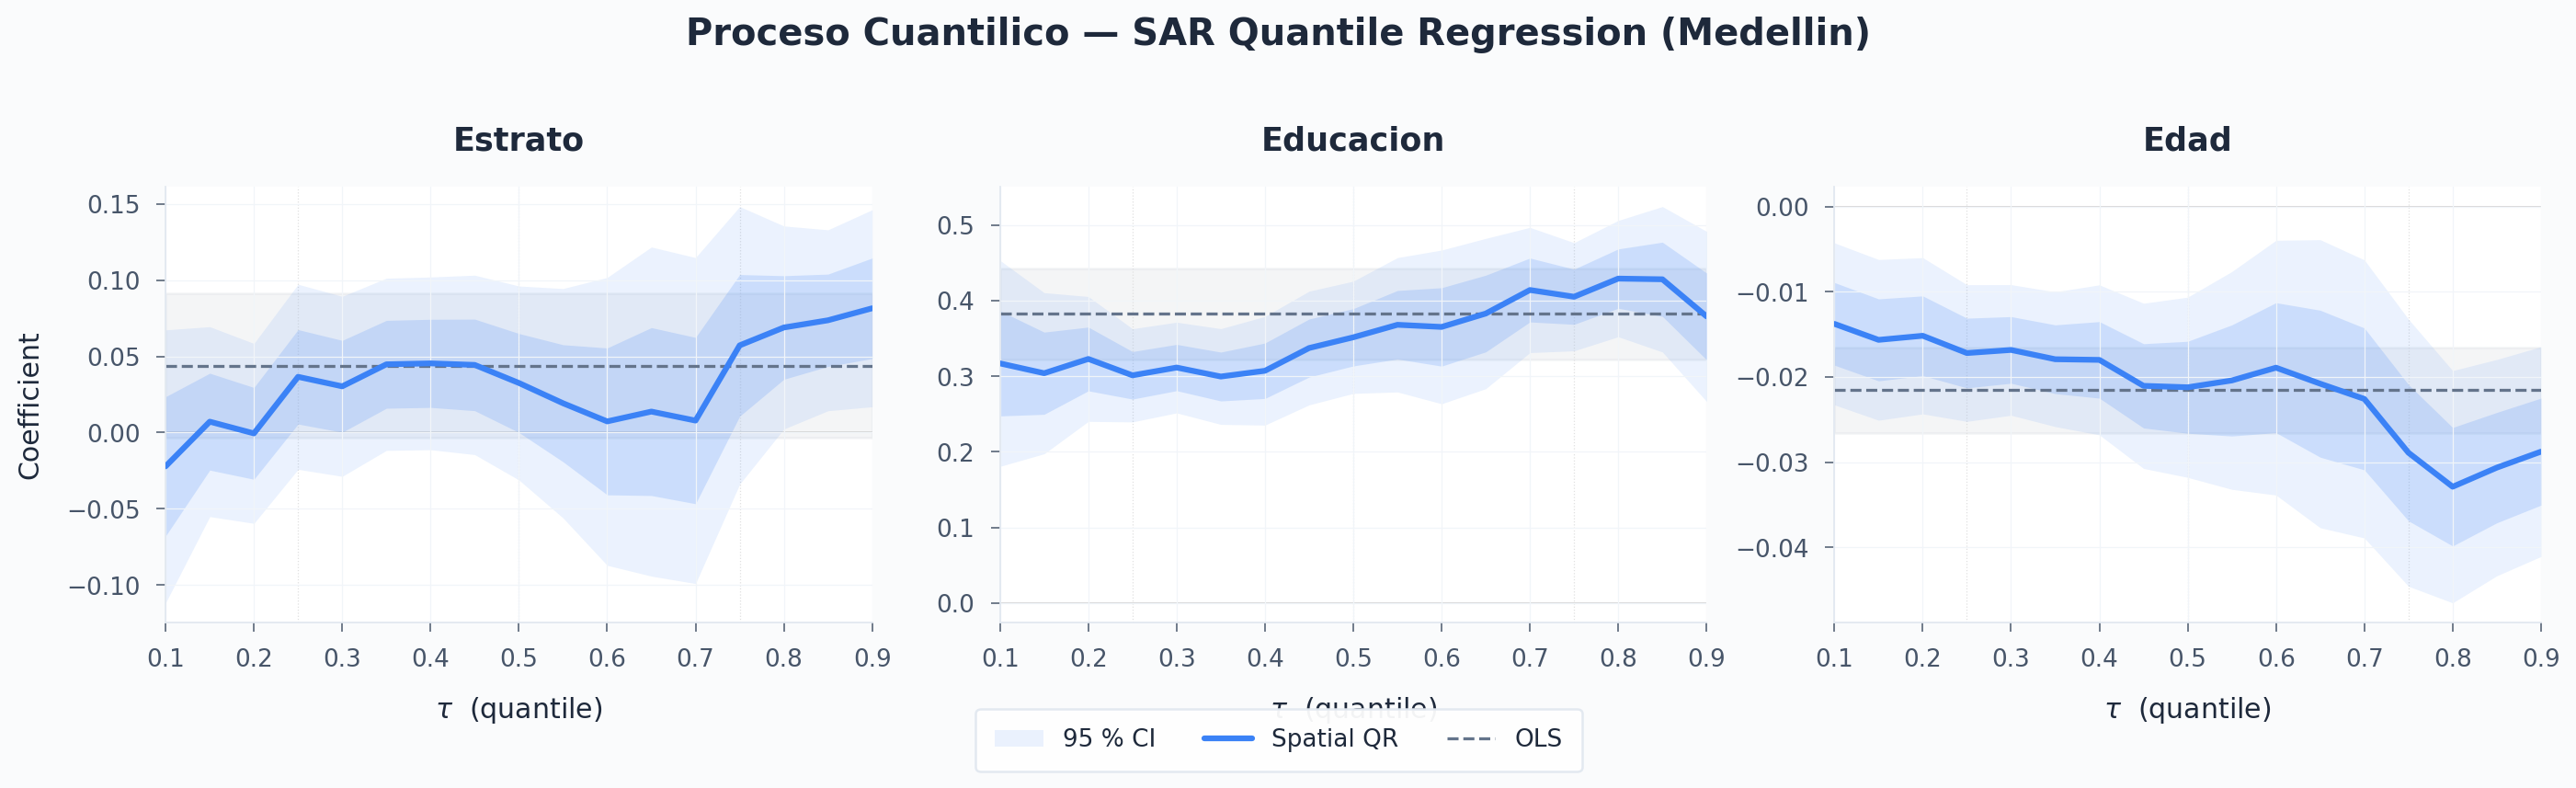

In [ ]:
# Graficar el proceso cuantilico
fig = plot_quantile_process(
    qp,
    title='Proceso Cuantilico — SAR Quantile Regression (Medellin)',
)
plt.show()

**Interpretacion:**

- Si el coeficiente del **Estrato** crece con $\tau$, significa que el estrato tiene
  mayor efecto sobre el ingreso en barrios de altos ingresos que en los de bajos ingresos.
- Un coeficiente de **Educacion** plano indica un efecto uniforme (location-shift).
- El parametro $\rho$ (autocorrelacion espacial) puede tambien variar: mayor $\rho$ en
  cuantiles bajos sugiere que los barrios pobres estan mas espacialmente agrupados.

---
## 6. Impactos Espaciales — Efectos Directos e Indirectos

En el modelo SAR, un cambio en una variable del barrio $j$ afecta a **todos** los barrios
a traves de la matriz multiplicadora $(I - \rho W)^{-1}$.

Los impactos se descomponen en:
- **Directo:** efecto sobre el propio barrio
- **Indirecto (spillover):** efecto que se propaga a barrios vecinos
- **Total:** suma de ambos

In [ ]:
# Impactos espaciales del modelo Two-Stage
print("=" * 65)
print("  Impactos Espaciales (LeSage & Pace) — Two-Stage, tau = 0.5")
print("=" * 65)
print(model_ts.impacts_.to_string(float_format=lambda x: f"{x:.5f}"))
print("=" * 65)
print()
print("Interpretacion:")
print("  El efecto indirecto (spillover) amplifica el efecto directo.")
print("  Por ejemplo, mejorar el estrato en un barrio no solo aumenta")
print("  el ingreso alli, sino que beneficia a los barrios vecinos.")

  Impactos Espaciales (LeSage & Pace) — Two-Stage, tau = 0.5
            Direct  SE Direct  Indirect (Spillover)  SE Indirect  p-val Indirect    Total  SE Total
Estrato    0.03254    0.03385               0.00072      0.00349         0.83613  0.03326   0.03599
Educacion  0.35187    0.03875               0.00781      0.02173         0.71923  0.35968   0.03758
Edad      -0.02121    0.00550              -0.00047      0.00147         0.74825 -0.02168   0.00597

Interpretacion:
  El efecto indirecto (spillover) amplifica el efecto directo.
  Por ejemplo, mejorar el estrato en un barrio no solo aumenta
  el ingreso alli, sino que beneficia a los barrios vecinos.


---
## 7. Diagnosticos Residuales

Si el modelo captura correctamente la dependencia espacial,
los residuales **no deberian** mostrar autocorrelacion espacial.

In [ ]:
# Residuales del modelo
y_hat_ts = model_ts.predict(X, W, y)
resid_ts = y - y_hat_ts

y_hat_gs = model_gs.predict(X, W, y)
resid_gs = y - y_hat_gs

print("=== Moran's I en Residuales: Two-Stage ===")
moran_test(resid_ts, W).summary()
print()
print("=== Moran's I en Residuales: Grid-Search ===")
moran_test(resid_gs, W).summary()

=== Moran's I en Residuales: Two-Stage ===
  Moran's I Test for Spatial Autocorrelation
  Moran's I statistic :  0.259882
  Expected value E[I] : -0.003704
  Variance Var[I]     :  0.001267
  Z-score             :  7.4056
  p-value (two-sided) :  0.000000
  Assumption          : randomization
  N                   : 271
-------------------------------------------------------
  Significant POSITIVE spatial autocorrelation

=== Moran's I en Residuales: Grid-Search ===
  Moran's I Test for Spatial Autocorrelation
  Moran's I statistic :  0.242112
  Expected value E[I] : -0.003704
  Variance Var[I]     :  0.001266
  Z-score             :  6.9077
  p-value (two-sided) :  0.000000
  Assumption          : randomization
  N                   : 271
-------------------------------------------------------
  Significant POSITIVE spatial autocorrelation


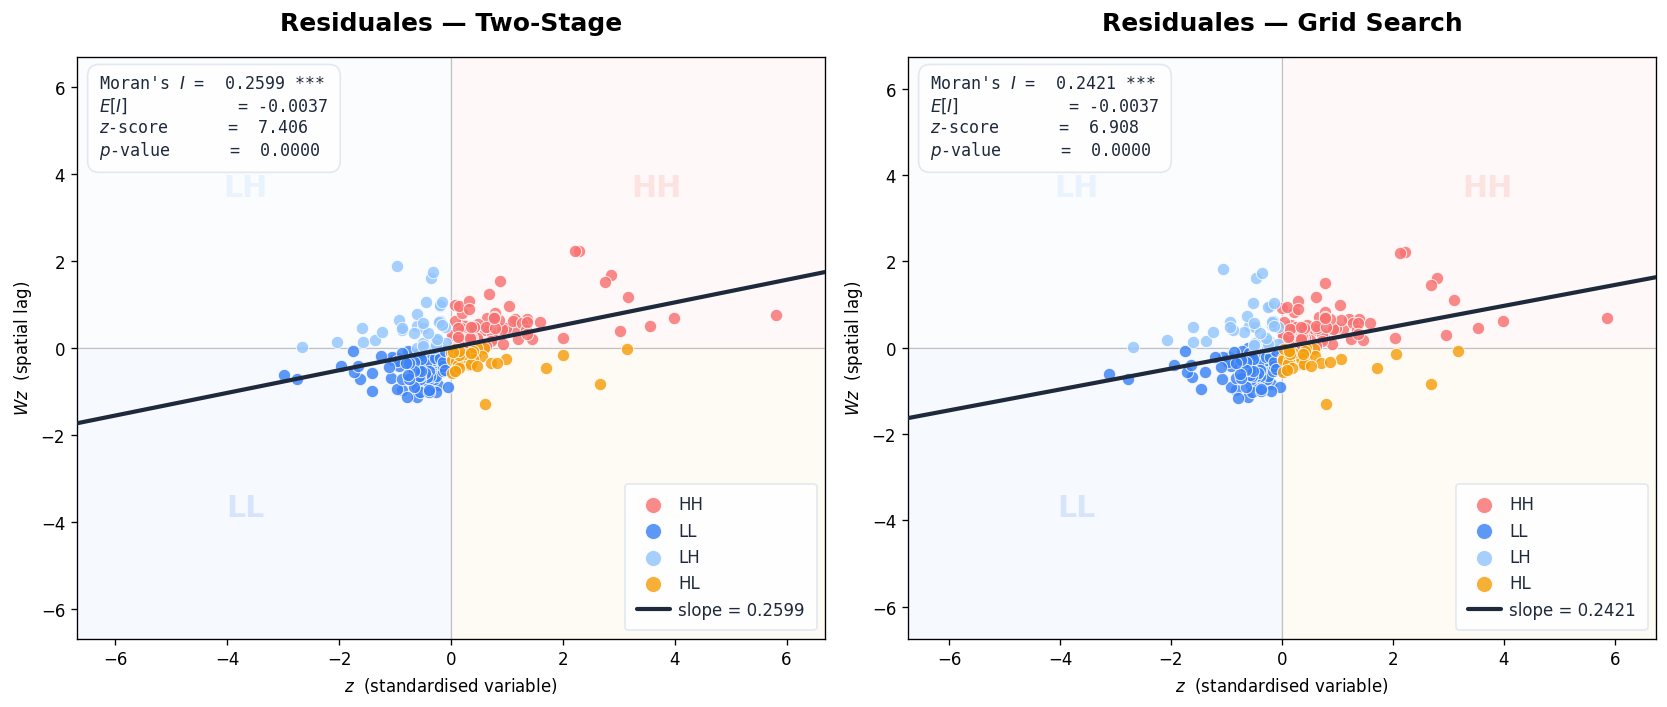

In [ ]:
# Moran scatterplots de residuales
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plot_moran(resid_ts, W, ax=axes[0], title='Residuales — Two-Stage')
plot_moran(resid_gs, W, ax=axes[1], title='Residuales — Grid Search')
plt.tight_layout()
plt.show()

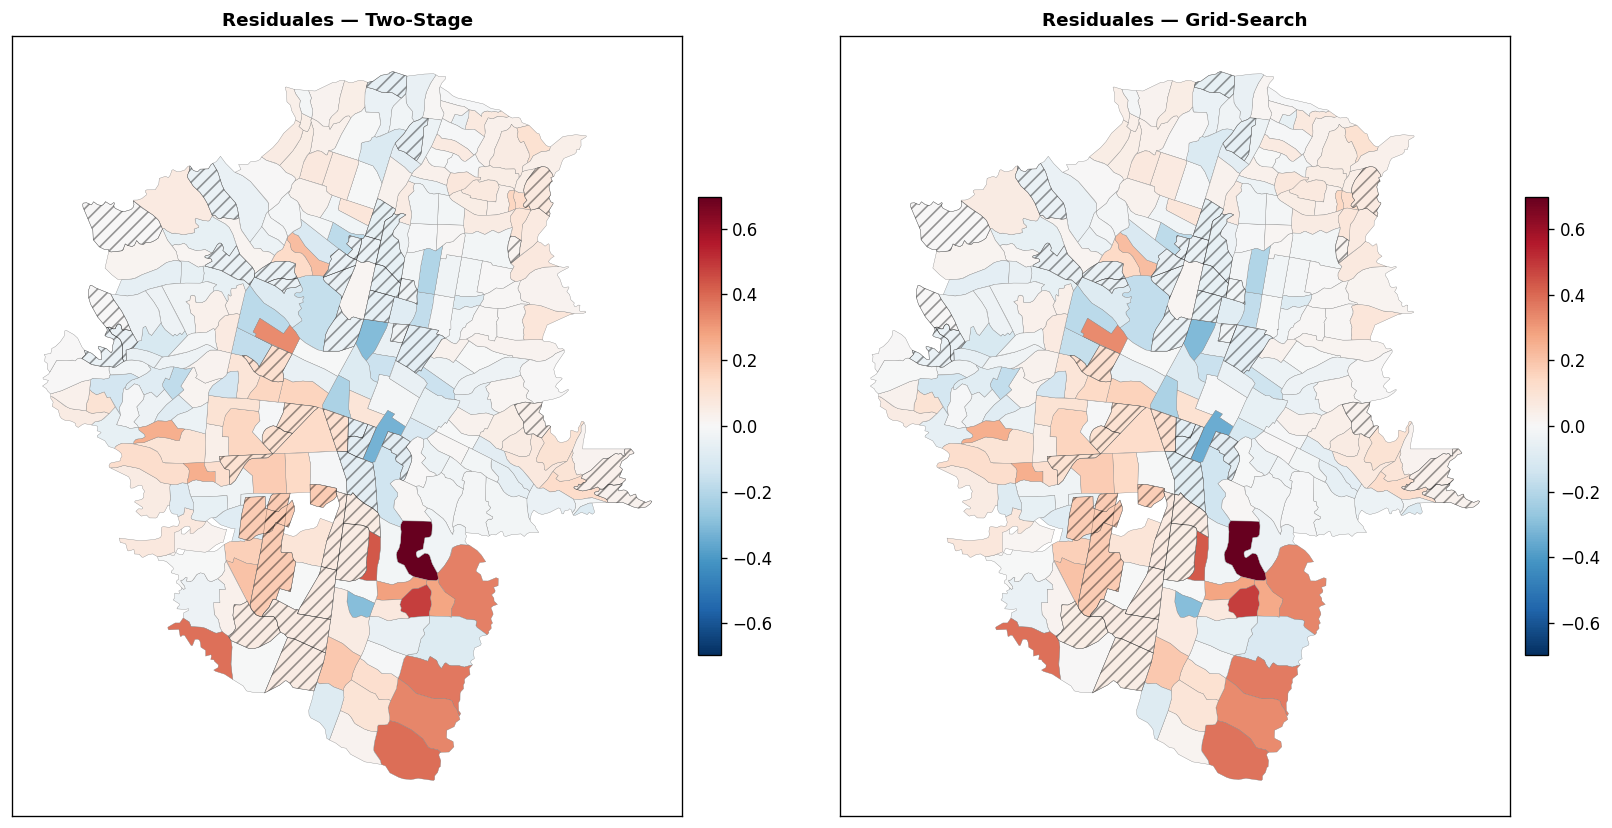

In [ ]:
# Mapa de residuales sobre los barrios
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

for ax, resid, label in zip(axes, [resid_ts, resid_gs], ['Two-Stage', 'Grid-Search']):
    vmax = max(abs(resid.min()), abs(resid.max()))
    pc = plot_choropleth(geometries, resid, ax, f'Residuales — {label}', cmap='RdBu_r',
                         imputado=df['imputado'].values)
    pc.set_clim(-vmax, vmax)
    plt.colorbar(pc, ax=ax, fraction=0.03, pad=0.02)

plt.tight_layout()
plt.show()

---
## 8. Comparacion entre cuantiles extremos

Comparemos los resultados en los cuantiles 0.25, 0.50 y 0.75 para ver
como cambian las relaciones en diferentes partes de la distribucion del ingreso.

In [ ]:
# Estimar en tres cuantiles
X_names = list(X.columns)
results = {}
for tau in [0.25, 0.50, 0.75]:
    model = QuantSAR(tau=tau, method='two_stage', nboot=200, random_state=42)
    model.fit(X, y, W)
    results[tau] = model
    print(f"\n{'='*55}")
    print(f"  tau = {tau}")
    print(f"{'='*55}")
    print(f"  rho    = {model.rho_:.4f}")
    print(f"  alpha  = {model.intercept_:.4f}")
    for name, coef in zip(X_names, model.coef_):
        print(f"  {name:12s} = {coef:.4f}")

# Tabla resumen
print(f"\n{'='*65}")
print(f"  {'Parametro':12s}  {'tau=0.25':>10s}  {'tau=0.50':>10s}  {'tau=0.75':>10s}")
print(f"{'='*65}")
print(f"  {'rho':12s}  {results[0.25].rho_:10.4f}  {results[0.50].rho_:10.4f}  {results[0.75].rho_:10.4f}")
print(f"  {'Intercepto':12s}  {results[0.25].intercept_:10.4f}  {results[0.50].intercept_:10.4f}  {results[0.75].intercept_:10.4f}")
for i, name in enumerate(X_names):
    print(f"  {name:12s}  {results[0.25].coef_[i]:10.4f}  {results[0.50].coef_[i]:10.4f}  {results[0.75].coef_[i]:10.4f}")
print(f"{'='*65}")


  tau = 0.25
  rho    = 0.0417
  alpha  = 12.5445
  Estrato      = 0.0366
  Educacion    = 0.3014
  Edad         = -0.0172



  tau = 0.5
  rho    = 0.0219
  alpha  = 12.8598
  Estrato      = 0.0325
  Educacion    = 0.3518
  Edad         = -0.0212



  tau = 0.75
  rho    = 0.0000
  alpha  = 13.2843
  Estrato      = 0.0572
  Educacion    = 0.4055
  Edad         = -0.0289

  Parametro       tau=0.25    tau=0.50    tau=0.75
  rho               0.0417      0.0219      0.0000
  Intercepto       12.5445     12.8598     13.2843
  Estrato           0.0366      0.0325      0.0572
  Educacion         0.3014      0.3518      0.4055
  Edad             -0.0172     -0.0212     -0.0289


---
## Resumen

| Paso | Herramienta PySQReg | Hallazgo |
|------|---------------------|----------|
| Moran's I | `moran_test`, `plot_moran` | Fuerte clustering espacial en ingresos y estrato |
| Modelo mediana | `QuantSAR(tau=0.5)` | Ambos metodos estiman $\rho$ significativo |
| Rho path | `plot_rho_path` | Cruce por cero claro confirma identificacion |
| Proceso cuantilico | `fit_quantile_process` | Efectos varian a lo largo de la distribucion |
| Modelos alternativos | `QuantSLX`, `QuantSDM` | Comparacion de especificaciones espaciales |
| Impactos espaciales | `model.impacts_` | Spillovers amplifican el efecto directo |
| Diagnosticos | `moran_test(resid, W)` | Verificacion de residuales |

**Ventaja vs. comunas:** Con 220 barrios (vs. 16 comunas) tenemos suficiente poder
estadistico para detectar diferencias entre cuantiles y estimar efectos espaciales
de forma robusta.

### Fuentes
- [MEData - Datos Abiertos Medellin](https://medata.gov.co/)
- [GeoMedellin - OpenData](https://geomedellin-m-medellin.opendata.arcgis.com/)
- [DANE - Censo 2018](https://geoportal.dane.gov.co/)